# Credit Risk Assessment System

## Introduction
This project uses machine learning techniques to predict loan approval outcomes based on applicant financial and demographic information. The objective is to identify high-risk applicants and support better lending decisions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Loading

In [2]:
df = pd.read_csv("/train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Exploratory Data Analysis

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


### Target Variable Distribution

In [4]:
df['Loan_Status'].value_counts()
df['Loan_Status'].value_counts(normalize=True)

,proportion
Loan_Status,
Y,0.687296
N,0.312704


### Class Distribution Analysis
The target variable (Loan_Status) showed moderate class imbalance, with approved loans occurring more frequently than rejected loans. To address this issue, class balancing techniques were applied during model training.

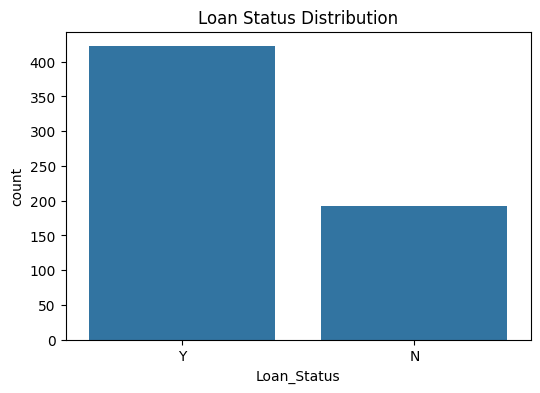

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)

plt.title('Loan Status Distribution')
plt.show()

## Data Cleaning
median imputation for numerical variables

In [6]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df=df.drop('Loan_ID', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


## Feature Engineering

Categorical variables were converted into numerical format to prepare the data for machine learning models.

In [7]:
df['Gender']=df['Gender'].map({'Male':1, 'Female':0})
df['Married']=df['Married'].map({'Yes':1, 'No':0})
df['Education']=df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed']=df['Self_Employed'].map({'Yes':1, 'No':0})
df['Loan_Status']=df['Loan_Status'].map({'Y':1, 'N':0})
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)
df=pd.get_dummies(df,columns=["Property_Area"], drop_first=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,False,True
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    bool   
 12  Property_Area_Urban      614 non-null    bool   
dtypes: bool(2), float64(4), int64(7)
memory usage: 54.1 KB


### Correlation Analysis

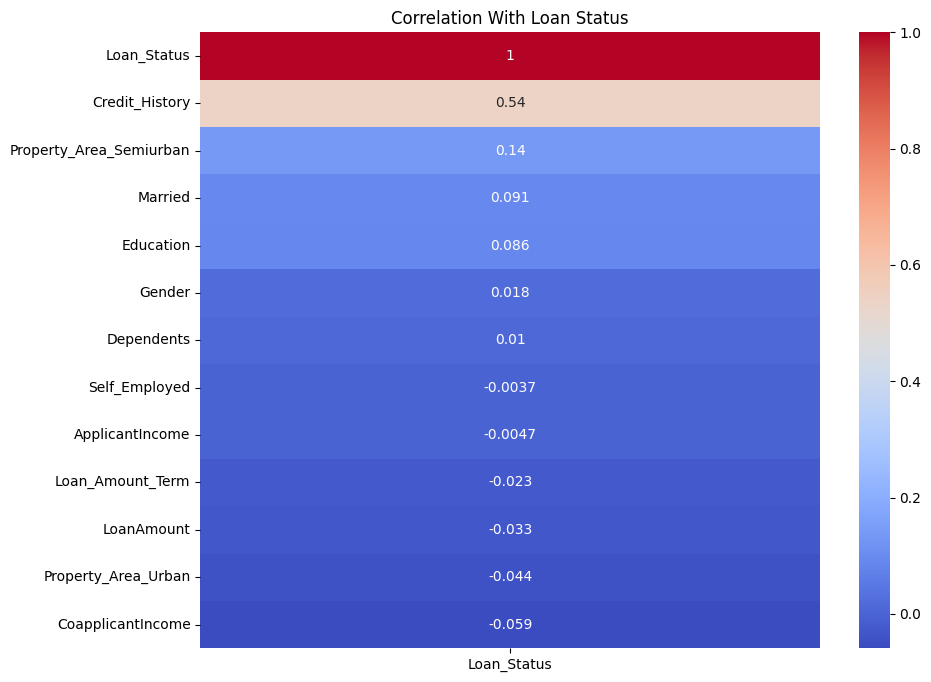

In [9]:
corr= df.corr()['Loan_Status'].sort_values(ascending=False)
plt.figure(figsize=(10,8))
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation With Loan Status')
plt.show()

In [10]:
df.groupby('Loan_Status')['Credit_History'].mean()

,Credit_History
Loan_Status,
0,0.572917
1,0.983412


### Observation

Credit_History showed the strongest positive correlation with loan approval, indicating that repayment behavior plays a major role in lending decisions.


## Model Building


In [11]:
X=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

scaler=StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### Logistic Regression

In [12]:
model = LogisticRegression(max_iter=5000,solver='liblinear')
model.fit(X_train,y_train)

LogisticRegression(max_iter=5000, solver='liblinear')

In [13]:
y_pred=model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Confusion Matrix:
[[18 25]
 [ 1 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



### Observation

The dataset shows moderate class imbalance, with approved loans appearing more frequently than rejected loans. This imbalance influenced model behavior and justified the use of class balancing techniques during training.

### Logistic Regression with class balancing

In [14]:
model = LogisticRegression(max_iter=2000,solver='liblinear',class_weight='balanced')
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

In [15]:
y_pred=model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Confusion Matrix:
[[22 21]
 [ 8 72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.51      0.60        43
           1       0.77      0.90      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.71      0.72       123
weighted avg       0.76      0.76      0.75       123



### Random Forest

In [16]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)


RandomForestClassifier(random_state=42)

In [17]:
y_pred_rf=rf_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test,y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



## Key Insights

- Credit history was the strongest predictor of loan approval.
- Logistic Regression with class balancing performed better at identifying risky applicants.
- Income influenced approval decisions but had weaker predictive power compared to credit behavior.

## Conclusion

This project demonstrates how machine learning can support financial institutions in evaluating loan applications and reducing default risk through data-driven decision-making.